# Superstore Sales Analysis

Author: Marlon Suero  
Tools Used: Python, pandas, matplotlib, seaborn  
Dataset: Superstore Retail Dataset  
Project Type: Exploratory Data Analysis (EDA)

---

## Project Objective
Analyze retail sales data to identify key revenue drivers, top customers, and seasonal sales patterns.

---

## Business Questions

1. Which product categories generate the most revenue?
2. Which customers generate the highest lifetime value?
3. Which regions produce the most sales?
4. Are there seasonal sales trends?

---

## Why This Analysis Matters
Retail companies rely on sales data to make decisions about product strategy, marketing, and inventory.  
Understanding which customers, products, and regions generate the most revenue helps businesses allocate resources effectively and maximize profit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create new columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [5]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


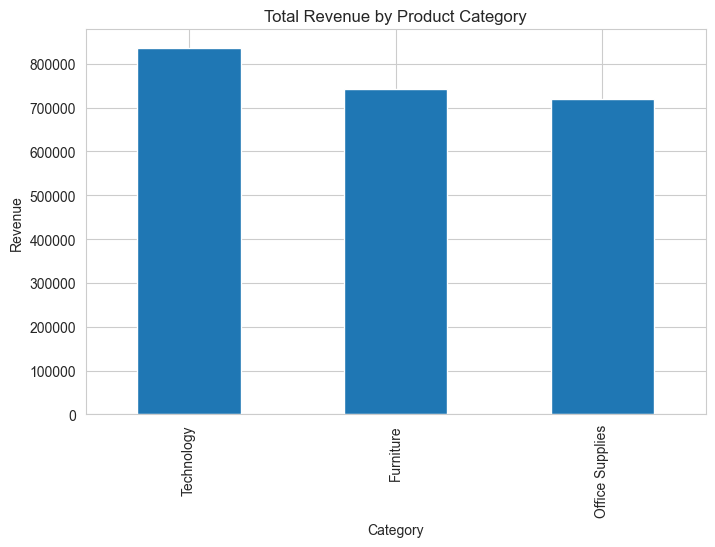

In [6]:
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Total Revenue by Product Category")
plt.ylabel("Revenue")
plt.xlabel("Category")

plt.show()

In [7]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


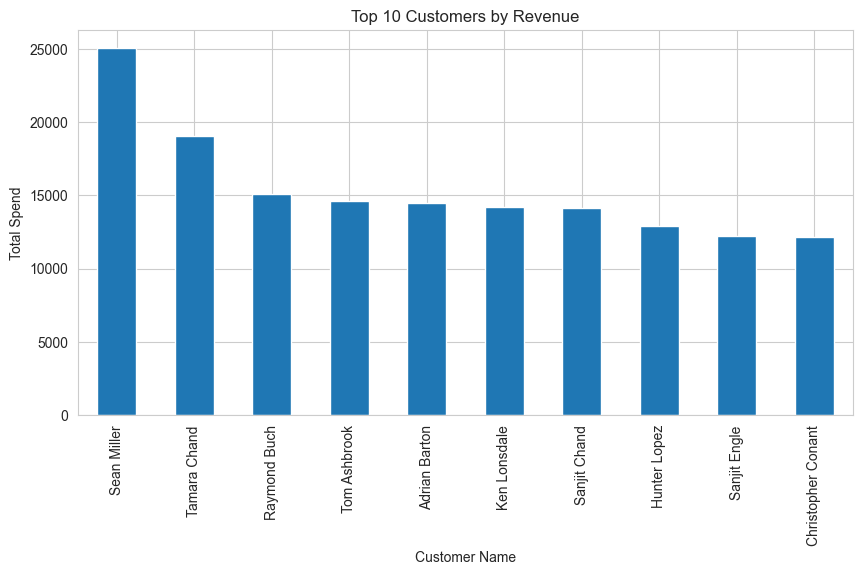

In [8]:
plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Total Spend")

plt.show()

In [9]:
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

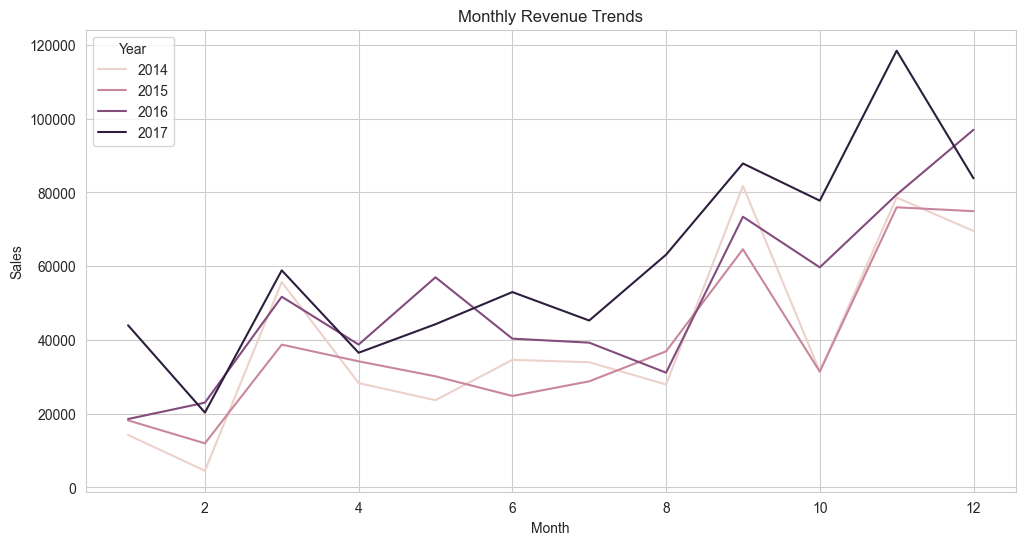

In [10]:
plt.figure(figsize=(12,6))

sns.lineplot(data=monthly_sales, x="Month", y="Sales", hue="Year")

plt.title("Monthly Revenue Trends")
plt.show()

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


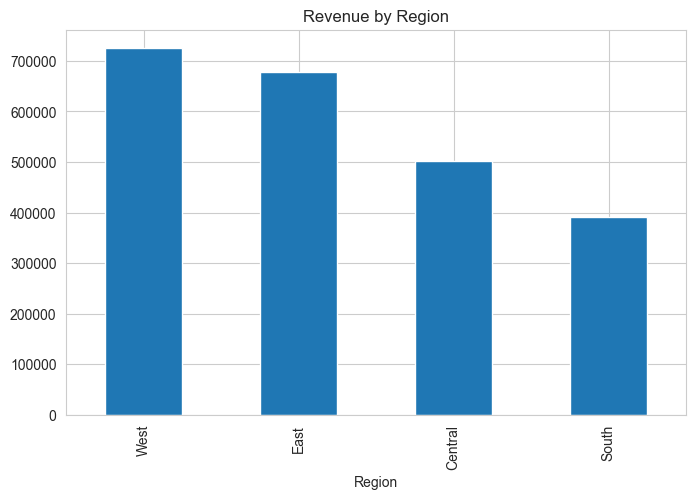

In [12]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Revenue by Region")

plt.show()

## Key Insights

1. **Technology products generate the highest total revenue**, followed by Furniture and Office Supplies.
2. **A small group of customers contribute disproportionately to overall sales**, highlighting the importance of high-value accounts.
3. **Sales show clear seasonal spikes** toward the end of the year, likely influenced by holiday shopping patterns.
4. **The West region consistently generates the most revenue** across the dataset.

---

## Conclusion

This analysis highlights the key revenue drivers for the Superstore dataset.  
Focusing on technology products, nurturing high-value customers, and planning for seasonal spikes can help management optimize inventory, marketing, and sales strategies.  

These findings demonstrate how data-driven insights can guide actionable business decisions.